In [1]:
from IPython.display import display, HTML 
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 1. 기존의 프로그램 방식
- 회귀분석(linear regression) 설명 사이트 : https://gbhat.com/machine_learning/linear_regression.html
- 오차함수 : MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE의 단점이 어느정도 해소. 이상치에 덜 민감), MAE(mean absolute error ; 절대값평균)
- https://jysden.medium.com/%EC%96%B8%EC%A0%9C-mse-mae-rmse%EB%A5%BC-%EC%82%AC%EC%9A%A9%ED%95%98%EB%8A%94%EA%B0%80-c473bd831c62
![image](https://miro.medium.com/v2/resize:fit:720/format:webp/1*XRXgMqrr5rq-V1rW7SkrtA.png)
- 경사하강법 설명
- https://www.mql5.com/ko/articles/11200

In [4]:
# 섭씨온도를 화씨온도를 출력
def celsius_to_faherenheit(c):
    return c * 1.8 + 32

In [5]:
input_c = int(input('섭씨온도 ?'))
print('화씨온도는', celsius_to_faherenheit(input_c))

섭씨온도 ?38
화씨온도는 100.4


# 2. 미신러닝 프로그램 방식
```
1. 데이터 확보 및 생성 [결측처 처리 포함]
2. 데이터 전처리 : 
    스케일 조정
    훈련데이터(학습데이터셋), 검증데이터셋, 시험데이터셋으로 분할
3. 모델구성
4. 모델 학습과정 설정
5. 모델 학습시키기
6. 모델 평가(시험데이터셋으로)
7. 모델 저장 및 사용(입력값이 주어지면 예측값 받기)
```
## 2.1 노이즈가 없는 데이터로 실습

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# 1. 데이터 생성
data_C = np.arange(100) # 0부터 99까지
data_C # 독립(입력) 변수

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [6]:
data_F = celsius_to_faherenheit(data_C)
data_F # 종속(타겟, 출력) 변수

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [7]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해 스케일 조정
scaled_data_C = data_C / 100.0
scaled_data_F = data_F / 100.0
print('학습시 독립변수 :', scaled_data_C)
print('학습시 타겟변수 :', scaled_data_F)

학습시 독립변수 : [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
학습시 타겟변수 : [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1

In [8]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

In [9]:
# 3. 모델 구성
from tensorflow.keras.models import Sequential   # 모델 생성
from tensorflow.keras.layers import Dense, Input # 입력값과 출력값으로 layer층 지정

model = Sequential()
# model.add(Input(shape=(1,) ))
# model.add(Dense(1))
model.add(Dense(units=1,           # 입력(독립) 변수의 shape
                input_shape=(1,))) # 타겟(종속) 변수의 갯수
                             

In [10]:
# 4. 모델 학습과정 설정
model.compile(loss="mse",         # 손실함수 - 모델 학습 중 오차를 최소화하기 위해 사용
             optimizer="rmsprop", # 옵티마이저
             metrics=['mae'])     # 평가지표
# mse : 오차 제곱의 평균(이상치 반영?)
# mae : 오차 절대값의 평균(이상치 영향이 감소)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [11]:
# 학습전 예측
model.predict(np.array([[0],
                       [0.01]])) # 섭씨온도 0, 1도는 화씨온도 몇도?

1/1 [==============================] - 0s 117ms/step


array([[ 0.        ],
       [-0.00886094]], dtype=float32)

In [16]:
# 학습전 모델 저장
model.save('model/before_learning.h5')

In [12]:
# 5. 모델 학습시키기 - 1번만 실행
hist = model.fit(scaled_data_C, # 입력변수(훈련데이터)
                scaled_data_F, # 타겟변수(훈련데이터)
                epochs = 1000, # 학습횟수
                verbose = 2)   # 학습시 출력여부 (0: 학습내용 출력x)

Epoch 1/1000
4/4 - 0s - loss: 3.3064 - mae: 1.6452 - 494ms/epoch - 124ms/step
Epoch 2/1000
4/4 - 0s - loss: 3.2641 - mae: 1.6334 - 8ms/epoch - 2ms/step
Epoch 3/1000
4/4 - 0s - loss: 3.2368 - mae: 1.6256 - 5ms/epoch - 1ms/step
Epoch 4/1000
4/4 - 0s - loss: 3.2122 - mae: 1.6187 - 15ms/epoch - 4ms/step
Epoch 5/1000
4/4 - 0s - loss: 3.1910 - mae: 1.6126 - 9ms/epoch - 2ms/step
Epoch 6/1000
4/4 - 0s - loss: 3.1709 - mae: 1.6069 - 6ms/epoch - 1ms/step
Epoch 7/1000
4/4 - 0s - loss: 3.1499 - mae: 1.6009 - 10ms/epoch - 3ms/step
Epoch 8/1000
4/4 - 0s - loss: 3.1293 - mae: 1.5950 - 9ms/epoch - 2ms/step
Epoch 9/1000
4/4 - 0s - loss: 3.1063 - mae: 1.5884 - 8ms/epoch - 2ms/step
Epoch 10/1000
4/4 - 0s - loss: 3.0869 - mae: 1.5828 - 6ms/epoch - 2ms/step
Epoch 11/1000
4/4 - 0s - loss: 3.0664 - mae: 1.5769 - 13ms/epoch - 3ms/step
Epoch 12/1000
4/4 - 0s - loss: 3.0457 - mae: 1.5709 - 7ms/epoch - 2ms/step
Epoch 13/1000
4/4 - 0s - loss: 3.0254 - mae: 1.5649 - 5ms/epoch - 1ms/step
Epoch 14/1000
4/4 - 0s - lo

Epoch 110/1000
4/4 - 0s - loss: 1.4255 - mae: 1.0076 - 0s/epoch - 0s/step
Epoch 111/1000
4/4 - 0s - loss: 1.4121 - mae: 1.0021 - 17ms/epoch - 4ms/step
Epoch 112/1000
4/4 - 0s - loss: 1.3987 - mae: 0.9968 - 0s/epoch - 0s/step
Epoch 113/1000
4/4 - 0s - loss: 1.3853 - mae: 0.9911 - 1ms/epoch - 328us/step
Epoch 114/1000
4/4 - 0s - loss: 1.3742 - mae: 0.9866 - 16ms/epoch - 4ms/step
Epoch 115/1000
4/4 - 0s - loss: 1.3619 - mae: 0.9814 - 6ms/epoch - 1ms/step
Epoch 116/1000
4/4 - 0s - loss: 1.3495 - mae: 0.9764 - 8ms/epoch - 2ms/step
Epoch 117/1000
4/4 - 0s - loss: 1.3366 - mae: 0.9711 - 8ms/epoch - 2ms/step
Epoch 118/1000
4/4 - 0s - loss: 1.3231 - mae: 0.9653 - 3ms/epoch - 642us/step
Epoch 119/1000
4/4 - 0s - loss: 1.3096 - mae: 0.9598 - 14ms/epoch - 4ms/step
Epoch 120/1000
4/4 - 0s - loss: 1.2966 - mae: 0.9542 - 5ms/epoch - 1ms/step
Epoch 121/1000
4/4 - 0s - loss: 1.2856 - mae: 0.9496 - 8ms/epoch - 2ms/step
Epoch 122/1000
4/4 - 0s - loss: 1.2739 - mae: 0.9447 - 0s/epoch - 0s/step
Epoch 123/1

4/4 - 0s - loss: 0.4398 - mae: 0.5460 - 6ms/epoch - 2ms/step
Epoch 218/1000
4/4 - 0s - loss: 0.4346 - mae: 0.5431 - 8ms/epoch - 2ms/step
Epoch 219/1000
4/4 - 0s - loss: 0.4290 - mae: 0.5400 - 6ms/epoch - 1ms/step
Epoch 220/1000
4/4 - 0s - loss: 0.4237 - mae: 0.5369 - 4ms/epoch - 898us/step
Epoch 221/1000
4/4 - 0s - loss: 0.4191 - mae: 0.5344 - 13ms/epoch - 3ms/step
Epoch 222/1000
4/4 - 0s - loss: 0.4134 - mae: 0.5310 - 3ms/epoch - 794us/step
Epoch 223/1000
4/4 - 0s - loss: 0.4075 - mae: 0.5276 - 9ms/epoch - 2ms/step
Epoch 224/1000
4/4 - 0s - loss: 0.4031 - mae: 0.5252 - 7ms/epoch - 2ms/step
Epoch 225/1000
4/4 - 0s - loss: 0.3981 - mae: 0.5222 - 6ms/epoch - 1ms/step
Epoch 226/1000
4/4 - 0s - loss: 0.3930 - mae: 0.5192 - 12ms/epoch - 3ms/step
Epoch 227/1000
4/4 - 0s - loss: 0.3875 - mae: 0.5160 - 7ms/epoch - 2ms/step
Epoch 228/1000
4/4 - 0s - loss: 0.3833 - mae: 0.5134 - 7ms/epoch - 2ms/step
Epoch 229/1000
4/4 - 0s - loss: 0.3786 - mae: 0.5106 - 12ms/epoch - 3ms/step
Epoch 230/1000
4/4 -

Epoch 325/1000
4/4 - 0s - loss: 0.1790 - mae: 0.3663 - 5ms/epoch - 1ms/step
Epoch 326/1000
4/4 - 0s - loss: 0.1781 - mae: 0.3654 - 5ms/epoch - 1ms/step
Epoch 327/1000
4/4 - 0s - loss: 0.1774 - mae: 0.3647 - 11ms/epoch - 3ms/step
Epoch 328/1000
4/4 - 0s - loss: 0.1766 - mae: 0.3639 - 5ms/epoch - 1ms/step
Epoch 329/1000
4/4 - 0s - loss: 0.1756 - mae: 0.3629 - 10ms/epoch - 3ms/step
Epoch 330/1000
4/4 - 0s - loss: 0.1747 - mae: 0.3619 - 7ms/epoch - 2ms/step
Epoch 331/1000
4/4 - 0s - loss: 0.1738 - mae: 0.3609 - 10ms/epoch - 3ms/step
Epoch 332/1000
4/4 - 0s - loss: 0.1729 - mae: 0.3599 - 9ms/epoch - 2ms/step
Epoch 333/1000
4/4 - 0s - loss: 0.1722 - mae: 0.3593 - 6ms/epoch - 1ms/step
Epoch 334/1000
4/4 - 0s - loss: 0.1714 - mae: 0.3584 - 4ms/epoch - 905us/step
Epoch 335/1000
4/4 - 0s - loss: 0.1707 - mae: 0.3577 - 6ms/epoch - 1ms/step
Epoch 336/1000
4/4 - 0s - loss: 0.1697 - mae: 0.3566 - 11ms/epoch - 3ms/step
Epoch 337/1000
4/4 - 0s - loss: 0.1690 - mae: 0.3559 - 6ms/epoch - 1ms/step
Epoch 

Epoch 432/1000
4/4 - 0s - loss: 0.1028 - mae: 0.2768 - 5ms/epoch - 1ms/step
Epoch 433/1000
4/4 - 0s - loss: 0.1022 - mae: 0.2761 - 7ms/epoch - 2ms/step
Epoch 434/1000
4/4 - 0s - loss: 0.1015 - mae: 0.2750 - 0s/epoch - 0s/step
Epoch 435/1000
4/4 - 0s - loss: 0.1010 - mae: 0.2742 - 5ms/epoch - 1ms/step
Epoch 436/1000
4/4 - 0s - loss: 0.1004 - mae: 0.2734 - 11ms/epoch - 3ms/step
Epoch 437/1000
4/4 - 0s - loss: 0.0998 - mae: 0.2727 - 8ms/epoch - 2ms/step
Epoch 438/1000
4/4 - 0s - loss: 0.0991 - mae: 0.2718 - 11ms/epoch - 3ms/step
Epoch 439/1000
4/4 - 0s - loss: 0.0985 - mae: 0.2709 - 5ms/epoch - 1ms/step
Epoch 440/1000
4/4 - 0s - loss: 0.0978 - mae: 0.2700 - 8ms/epoch - 2ms/step
Epoch 441/1000
4/4 - 0s - loss: 0.0971 - mae: 0.2690 - 7ms/epoch - 2ms/step
Epoch 442/1000
4/4 - 0s - loss: 0.0964 - mae: 0.2681 - 8ms/epoch - 2ms/step
Epoch 443/1000
4/4 - 0s - loss: 0.0956 - mae: 0.2671 - 10ms/epoch - 3ms/step
Epoch 444/1000
4/4 - 0s - loss: 0.0951 - mae: 0.2665 - 0s/epoch - 0s/step
Epoch 445/100

Epoch 540/1000
4/4 - 0s - loss: 0.0472 - mae: 0.1873 - 9ms/epoch - 2ms/step
Epoch 541/1000
4/4 - 0s - loss: 0.0467 - mae: 0.1864 - 7ms/epoch - 2ms/step
Epoch 542/1000
4/4 - 0s - loss: 0.0463 - mae: 0.1855 - 9ms/epoch - 2ms/step
Epoch 543/1000
4/4 - 0s - loss: 0.0458 - mae: 0.1847 - 0s/epoch - 0s/step
Epoch 544/1000
4/4 - 0s - loss: 0.0454 - mae: 0.1838 - 18ms/epoch - 4ms/step
Epoch 545/1000
4/4 - 0s - loss: 0.0451 - mae: 0.1831 - 0s/epoch - 0s/step
Epoch 546/1000
4/4 - 0s - loss: 0.0447 - mae: 0.1824 - 3ms/epoch - 755us/step
Epoch 547/1000
4/4 - 0s - loss: 0.0443 - mae: 0.1815 - 14ms/epoch - 4ms/step
Epoch 548/1000
4/4 - 0s - loss: 0.0439 - mae: 0.1806 - 3ms/epoch - 645us/step
Epoch 549/1000
4/4 - 0s - loss: 0.0435 - mae: 0.1797 - 11ms/epoch - 3ms/step
Epoch 550/1000
4/4 - 0s - loss: 0.0432 - mae: 0.1789 - 0s/epoch - 0s/step
Epoch 551/1000
4/4 - 0s - loss: 0.0428 - mae: 0.1783 - 16ms/epoch - 4ms/step
Epoch 552/1000
4/4 - 0s - loss: 0.0425 - mae: 0.1778 - 11ms/epoch - 3ms/step
Epoch 553

Epoch 648/1000
4/4 - 0s - loss: 0.0126 - mae: 0.0971 - 12ms/epoch - 3ms/step
Epoch 649/1000
4/4 - 0s - loss: 0.0125 - mae: 0.0964 - 6ms/epoch - 2ms/step
Epoch 650/1000
4/4 - 0s - loss: 0.0122 - mae: 0.0956 - 13ms/epoch - 3ms/step
Epoch 651/1000
4/4 - 0s - loss: 0.0120 - mae: 0.0946 - 0s/epoch - 0s/step
Epoch 652/1000
4/4 - 0s - loss: 0.0118 - mae: 0.0940 - 14ms/epoch - 4ms/step
Epoch 653/1000
4/4 - 0s - loss: 0.0116 - mae: 0.0929 - 0s/epoch - 0s/step
Epoch 654/1000
4/4 - 0s - loss: 0.0114 - mae: 0.0922 - 6ms/epoch - 1ms/step
Epoch 655/1000
4/4 - 0s - loss: 0.0112 - mae: 0.0912 - 8ms/epoch - 2ms/step
Epoch 656/1000
4/4 - 0s - loss: 0.0109 - mae: 0.0903 - 5ms/epoch - 1ms/step
Epoch 657/1000
4/4 - 0s - loss: 0.0108 - mae: 0.0897 - 12ms/epoch - 3ms/step
Epoch 658/1000
4/4 - 0s - loss: 0.0106 - mae: 0.0891 - 3ms/epoch - 693us/step
Epoch 659/1000
4/4 - 0s - loss: 0.0104 - mae: 0.0882 - 13ms/epoch - 3ms/step
Epoch 660/1000
4/4 - 0s - loss: 0.0102 - mae: 0.0875 - 5ms/epoch - 1ms/step
Epoch 661

Epoch 755/1000
4/4 - 0s - loss: 2.0937e-04 - mae: 0.0125 - 5ms/epoch - 1ms/step
Epoch 756/1000
4/4 - 0s - loss: 1.8380e-04 - mae: 0.0117 - 11ms/epoch - 3ms/step
Epoch 757/1000
4/4 - 0s - loss: 1.6615e-04 - mae: 0.0112 - 6ms/epoch - 2ms/step
Epoch 758/1000
4/4 - 0s - loss: 1.4576e-04 - mae: 0.0105 - 8ms/epoch - 2ms/step
Epoch 759/1000
4/4 - 0s - loss: 1.2781e-04 - mae: 0.0098 - 6ms/epoch - 2ms/step
Epoch 760/1000
4/4 - 0s - loss: 1.0738e-04 - mae: 0.0089 - 7ms/epoch - 2ms/step
Epoch 761/1000
4/4 - 0s - loss: 9.0062e-05 - mae: 0.0082 - 10ms/epoch - 2ms/step
Epoch 762/1000
4/4 - 0s - loss: 7.3728e-05 - mae: 0.0074 - 6ms/epoch - 1ms/step
Epoch 763/1000
4/4 - 0s - loss: 6.5658e-05 - mae: 0.0069 - 8ms/epoch - 2ms/step
Epoch 764/1000
4/4 - 0s - loss: 5.3289e-05 - mae: 0.0062 - 3ms/epoch - 738us/step
Epoch 765/1000
4/4 - 0s - loss: 4.3475e-05 - mae: 0.0056 - 11ms/epoch - 3ms/step
Epoch 766/1000
4/4 - 0s - loss: 3.4096e-05 - mae: 0.0051 - 4ms/epoch - 1ms/step
Epoch 767/1000
4/4 - 0s - loss: 2.5

Epoch 854/1000
4/4 - 0s - loss: 5.6813e-07 - mae: 7.3076e-04 - 12ms/epoch - 3ms/step
Epoch 855/1000
4/4 - 0s - loss: 4.2140e-07 - mae: 6.3494e-04 - 7ms/epoch - 2ms/step
Epoch 856/1000
4/4 - 0s - loss: 6.0773e-07 - mae: 7.6266e-04 - 11ms/epoch - 3ms/step
Epoch 857/1000
4/4 - 0s - loss: 7.9574e-07 - mae: 8.7251e-04 - 6ms/epoch - 2ms/step
Epoch 858/1000
4/4 - 0s - loss: 4.9033e-07 - mae: 6.8447e-04 - 10ms/epoch - 3ms/step
Epoch 859/1000
4/4 - 0s - loss: 3.4202e-07 - mae: 5.7440e-04 - 2ms/epoch - 484us/step
Epoch 860/1000
4/4 - 0s - loss: 1.1958e-06 - mae: 0.0011 - 11ms/epoch - 3ms/step
Epoch 861/1000
4/4 - 0s - loss: 3.9146e-07 - mae: 6.0847e-04 - 0s/epoch - 0s/step
Epoch 862/1000
4/4 - 0s - loss: 2.2694e-07 - mae: 4.6323e-04 - 7ms/epoch - 2ms/step
Epoch 863/1000
4/4 - 0s - loss: 8.9452e-07 - mae: 9.1932e-04 - 10ms/epoch - 2ms/step
Epoch 864/1000
4/4 - 0s - loss: 6.1228e-07 - mae: 7.5761e-04 - 4ms/epoch - 985us/step
Epoch 865/1000
4/4 - 0s - loss: 5.8405e-07 - mae: 7.4730e-04 - 14ms/epoch

Epoch 952/1000
4/4 - 0s - loss: 2.0331e-07 - mae: 4.3249e-04 - 5ms/epoch - 1ms/step
Epoch 953/1000
4/4 - 0s - loss: 1.0603e-06 - mae: 0.0010 - 11ms/epoch - 3ms/step
Epoch 954/1000
4/4 - 0s - loss: 9.1066e-07 - mae: 9.2221e-04 - 6ms/epoch - 1ms/step
Epoch 955/1000
4/4 - 0s - loss: 9.0653e-08 - mae: 2.9380e-04 - 6ms/epoch - 1ms/step
Epoch 956/1000
4/4 - 0s - loss: 3.7670e-07 - mae: 5.8748e-04 - 10ms/epoch - 2ms/step
Epoch 957/1000
4/4 - 0s - loss: 1.0945e-06 - mae: 0.0010 - 2ms/epoch - 392us/step
Epoch 958/1000
4/4 - 0s - loss: 3.7737e-07 - mae: 6.0257e-04 - 14ms/epoch - 3ms/step
Epoch 959/1000
4/4 - 0s - loss: 1.7042e-07 - mae: 3.9992e-04 - 7ms/epoch - 2ms/step
Epoch 960/1000
4/4 - 0s - loss: 9.1544e-07 - mae: 9.2200e-04 - 10ms/epoch - 3ms/step
Epoch 961/1000
4/4 - 0s - loss: 1.3681e-07 - mae: 3.5114e-04 - 0s/epoch - 0s/step
Epoch 962/1000
4/4 - 0s - loss: 6.9535e-07 - mae: 8.0010e-04 - 4ms/epoch - 1ms/step
Epoch 963/1000
4/4 - 0s - loss: 1.1316e-06 - mae: 0.0010 - 12ms/epoch - 3ms/step

In [13]:
# 6. 모델 평가(그래프를 통해 loss와 metrics값의 추이, 평가함수)
print(hist.history.keys())
print(hist.history['loss'][:5])
print(hist.history['mae'][:5])

dict_keys(['loss', 'mae'])
[3.3064310550689697, 3.2641189098358154, 3.236752986907959, 3.212188720703125, 3.1909987926483154]
[1.645168423652649, 1.6334260702133179, 1.6256208419799805, 1.6187233924865723, 1.6126103401184082]


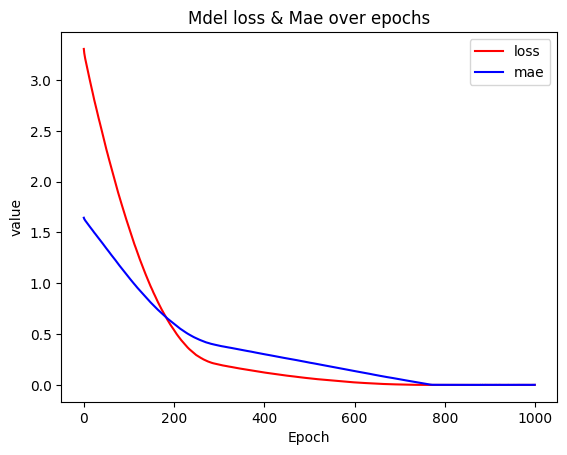

In [14]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend()  # 범례 label 추가
plt.xlabel('Epoch')
plt.ylabel('value')
plt.title('Mdel loss & Mae over epochs')
plt.show()

In [15]:
# 7. 모델 저장 및 사용
# 학습후 예측
model.predict(np.array([[0],
                       [0.01]])) # 섭씨온도 0, 1도는 화씨온도 몇도?

1/1 [==============================] - 0s 34ms/step


array([[0.31938067],
       [0.33737585]], dtype=float32)

In [26]:
model.save('model/after_learning.h5')

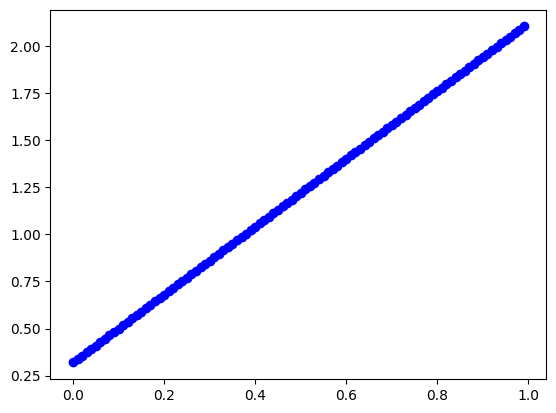

In [19]:
# 실제값
plt.scatter(x=scaled_data_C,
           y=scaled_data_F,
           c='b')
plt.show()

In [20]:
# 예측값
y_hat = model.predict([scaled_data_C])
for h, y in zip(y_hat, scaled_data_F):
    print('예측값: {}, 실제값: {}, 오차: {}'.format(h, y, h[0]-y))


4/4 [==============================] - 0s 2ms/step
예측값: [0.31938067], 실제값: 0.32, 오차: -0.000619329214096076
예측값: [0.33737585], 실제값: 0.33799999999999997, 오차: -0.0006241505146026283
예측값: [0.355371], 실제값: 0.35600000000000004, 오차: -0.0006290016174316793
예측값: [0.37336618], 실제값: 0.374, 오차: -0.0006338229179382315
예측값: [0.39136133], 실제값: 0.392, 오차: -0.000638674020767227
예측값: [0.4093565], 실제값: 0.41, 오차: -0.0006434953212737793
예측값: [0.42735165], 실제값: 0.428, 오차: -0.0006483464241027748
예측값: [0.44534683], 실제값: 0.446, 오차: -0.0006531677246093825
예측값: [0.463342], 실제값: 0.46399999999999997, 오차: -0.0006579890251159348
예측값: [0.4813372], 실제값: 0.48200000000000004, 오차: -0.0006628103256225981
예측값: [0.49933234], 실제값: 0.5, 오차: -0.0006676614284515381
예측값: [0.5173275], 실제값: 0.518, 오차: -0.0006725125312805336
예측값: [0.53532267], 실제값: 0.536, 오차: -0.0006773338317871413
예측값: [0.55331784], 실제값: 0.554, 오차: -0.0006821551322937491
예측값: [0.571313], 실제값: 0.5720000000000001, 오차: -0.0006869764328003569
예측값: [0.58930814], 실제값: 0

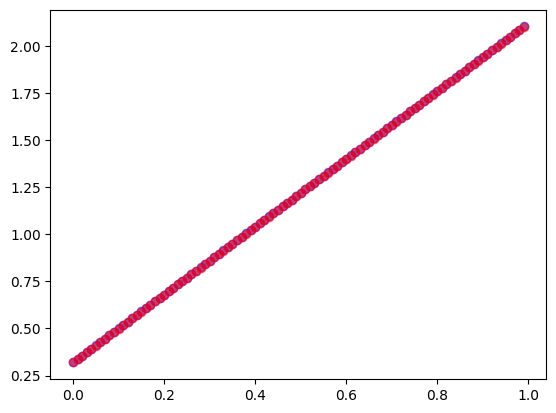

In [21]:
plt.scatter(x=scaled_data_C, y=scaled_data_F, c='b', alpha=0.5)
plt.scatter(x=scaled_data_C, y=y_hat, c='r', alpha=0.5)
plt.show()

## 2.2 노이즈가 있는 데이터로 실습

In [47]:
# np.random.seed(7)
noise = np.random.normal(0, scale=0.1, size=100) # 평균 0, 표준편차 0.1의 100개 데이터
noised_scaled_data_F = scaled_data_F + noise

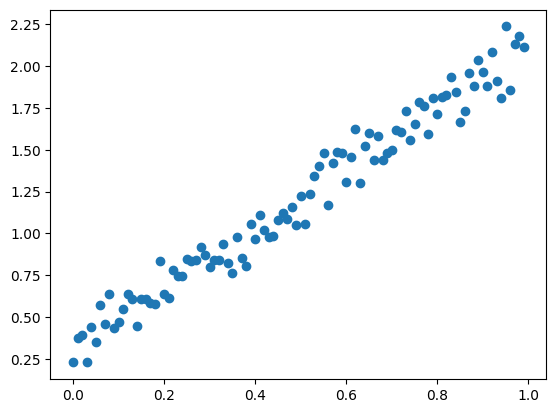

In [48]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F)
plt.show()

In [49]:
# 3. 모델 구성
model2 = Sequential()
model2.add(Dense(1, input_shape=(1,)))
# 4. 학습과정 설정
model2.compile(loss="mse", optimizer="rmsprop", metrics=['mae']) 
model2.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [50]:
# 5. 모델 학습시키기 - 1번만 실행
hist2 = model2.fit(scaled_data_C, # 입력변수(훈련데이터)
                noised_scaled_data_F, # 타겟변수(훈련데이터)
                epochs = 1000, # 학습횟수
                verbose = 2)   # 학습시 출력여부 (0: 학습내용 출력x)

Epoch 1/1000
4/4 - 0s - loss: 5.0204 - mae: 2.0076 - 381ms/epoch - 95ms/step
Epoch 2/1000
4/4 - 0s - loss: 4.9700 - mae: 1.9964 - 9ms/epoch - 2ms/step
Epoch 3/1000
4/4 - 0s - loss: 4.9350 - mae: 1.9883 - 8ms/epoch - 2ms/step
Epoch 4/1000
4/4 - 0s - loss: 4.9069 - mae: 1.9819 - 0s/epoch - 0s/step
Epoch 5/1000
4/4 - 0s - loss: 4.8805 - mae: 1.9757 - 4ms/epoch - 1ms/step
Epoch 6/1000
4/4 - 0s - loss: 4.8538 - mae: 1.9696 - 13ms/epoch - 3ms/step
Epoch 7/1000
4/4 - 0s - loss: 4.8257 - mae: 1.9630 - 5ms/epoch - 1ms/step
Epoch 8/1000
4/4 - 0s - loss: 4.7992 - mae: 1.9569 - 13ms/epoch - 3ms/step
Epoch 9/1000
4/4 - 0s - loss: 4.7742 - mae: 1.9511 - 0s/epoch - 0s/step
Epoch 10/1000
4/4 - 0s - loss: 4.7480 - mae: 1.9449 - 2ms/epoch - 507us/step
Epoch 11/1000
4/4 - 0s - loss: 4.7211 - mae: 1.9386 - 15ms/epoch - 4ms/step
Epoch 12/1000
4/4 - 0s - loss: 4.6959 - mae: 1.9327 - 0s/epoch - 0s/step
Epoch 13/1000
4/4 - 0s - loss: 4.6711 - mae: 1.9268 - 18ms/epoch - 5ms/step
Epoch 14/1000
4/4 - 0s - loss: 

Epoch 110/1000
4/4 - 0s - loss: 2.6168 - mae: 1.3719 - 3ms/epoch - 727us/step
Epoch 111/1000
4/4 - 0s - loss: 2.5981 - mae: 1.3661 - 13ms/epoch - 3ms/step
Epoch 112/1000
4/4 - 0s - loss: 2.5806 - mae: 1.3608 - 0s/epoch - 0s/step
Epoch 113/1000
4/4 - 0s - loss: 2.5635 - mae: 1.3556 - 2ms/epoch - 513us/step
Epoch 114/1000
4/4 - 0s - loss: 2.5468 - mae: 1.3503 - 13ms/epoch - 3ms/step
Epoch 115/1000
4/4 - 0s - loss: 2.5316 - mae: 1.3455 - 5ms/epoch - 1ms/step
Epoch 116/1000
4/4 - 0s - loss: 2.5157 - mae: 1.3406 - 11ms/epoch - 3ms/step
Epoch 117/1000
4/4 - 0s - loss: 2.4964 - mae: 1.3346 - 7ms/epoch - 2ms/step
Epoch 118/1000
4/4 - 0s - loss: 2.4787 - mae: 1.3291 - 11ms/epoch - 3ms/step
Epoch 119/1000
4/4 - 0s - loss: 2.4627 - mae: 1.3240 - 0s/epoch - 0s/step
Epoch 120/1000
4/4 - 0s - loss: 2.4454 - mae: 1.3186 - 18ms/epoch - 4ms/step
Epoch 121/1000
4/4 - 0s - loss: 2.4271 - mae: 1.3128 - 0s/epoch - 0s/step
Epoch 122/1000
4/4 - 0s - loss: 2.4123 - mae: 1.3081 - 4ms/epoch - 1ms/step
Epoch 123

4/4 - 0s - loss: 1.1306 - mae: 0.8618 - 2ms/epoch - 410us/step
Epoch 218/1000
4/4 - 0s - loss: 1.1213 - mae: 0.8583 - 15ms/epoch - 4ms/step
Epoch 219/1000
4/4 - 0s - loss: 1.1129 - mae: 0.8548 - 3ms/epoch - 650us/step
Epoch 220/1000
4/4 - 0s - loss: 1.1019 - mae: 0.8507 - 3ms/epoch - 791us/step
Epoch 221/1000
4/4 - 0s - loss: 1.0912 - mae: 0.8463 - 10ms/epoch - 2ms/step
Epoch 222/1000
4/4 - 0s - loss: 1.0819 - mae: 0.8427 - 4ms/epoch - 946us/step
Epoch 223/1000
4/4 - 0s - loss: 1.0718 - mae: 0.8386 - 11ms/epoch - 3ms/step
Epoch 224/1000
4/4 - 0s - loss: 1.0607 - mae: 0.8342 - 0s/epoch - 0s/step
Epoch 225/1000
4/4 - 0s - loss: 1.0503 - mae: 0.8299 - 15ms/epoch - 4ms/step
Epoch 226/1000
4/4 - 0s - loss: 1.0425 - mae: 0.8267 - 0s/epoch - 0s/step
Epoch 227/1000
4/4 - 0s - loss: 1.0336 - mae: 0.8231 - 17ms/epoch - 4ms/step
Epoch 228/1000
4/4 - 0s - loss: 1.0235 - mae: 0.8187 - 0s/epoch - 0s/step
Epoch 229/1000
4/4 - 0s - loss: 1.0142 - mae: 0.8150 - 18ms/epoch - 4ms/step
Epoch 230/1000
4/4 

Epoch 325/1000
4/4 - 0s - loss: 0.4383 - mae: 0.5648 - 7ms/epoch - 2ms/step
Epoch 326/1000
4/4 - 0s - loss: 0.4357 - mae: 0.5635 - 9ms/epoch - 2ms/step
Epoch 327/1000
4/4 - 0s - loss: 0.4330 - mae: 0.5621 - 5ms/epoch - 1ms/step
Epoch 328/1000
4/4 - 0s - loss: 0.4309 - mae: 0.5609 - 9ms/epoch - 2ms/step
Epoch 329/1000
4/4 - 0s - loss: 0.4277 - mae: 0.5593 - 0s/epoch - 0s/step
Epoch 330/1000
4/4 - 0s - loss: 0.4256 - mae: 0.5581 - 8ms/epoch - 2ms/step
Epoch 331/1000
4/4 - 0s - loss: 0.4223 - mae: 0.5566 - 9ms/epoch - 2ms/step
Epoch 332/1000
4/4 - 0s - loss: 0.4204 - mae: 0.5556 - 5ms/epoch - 1ms/step
Epoch 333/1000
4/4 - 0s - loss: 0.4179 - mae: 0.5545 - 8ms/epoch - 2ms/step
Epoch 334/1000
4/4 - 0s - loss: 0.4153 - mae: 0.5532 - 9ms/epoch - 2ms/step
Epoch 335/1000
4/4 - 0s - loss: 0.4130 - mae: 0.5522 - 8ms/epoch - 2ms/step
Epoch 336/1000
4/4 - 0s - loss: 0.4113 - mae: 0.5514 - 4ms/epoch - 1ms/step
Epoch 337/1000
4/4 - 0s - loss: 0.4085 - mae: 0.5501 - 15ms/epoch - 4ms/step
Epoch 338/100

Epoch 433/1000
4/4 - 0s - loss: 0.2868 - mae: 0.4715 - 7ms/epoch - 2ms/step
Epoch 434/1000
4/4 - 0s - loss: 0.2856 - mae: 0.4705 - 6ms/epoch - 1ms/step
Epoch 435/1000
4/4 - 0s - loss: 0.2846 - mae: 0.4697 - 6ms/epoch - 1ms/step
Epoch 436/1000
4/4 - 0s - loss: 0.2837 - mae: 0.4690 - 11ms/epoch - 3ms/step
Epoch 437/1000
4/4 - 0s - loss: 0.2828 - mae: 0.4682 - 7ms/epoch - 2ms/step
Epoch 438/1000
4/4 - 0s - loss: 0.2818 - mae: 0.4675 - 4ms/epoch - 1ms/step
Epoch 439/1000
4/4 - 0s - loss: 0.2808 - mae: 0.4666 - 838us/epoch - 210us/step
Epoch 440/1000
4/4 - 0s - loss: 0.2797 - mae: 0.4657 - 0s/epoch - 0s/step
Epoch 441/1000
4/4 - 0s - loss: 0.2787 - mae: 0.4648 - 3ms/epoch - 818us/step
Epoch 442/1000
4/4 - 0s - loss: 0.2776 - mae: 0.4639 - 13ms/epoch - 3ms/step
Epoch 443/1000
4/4 - 0s - loss: 0.2765 - mae: 0.4630 - 3ms/epoch - 808us/step
Epoch 444/1000
4/4 - 0s - loss: 0.2753 - mae: 0.4620 - 11ms/epoch - 3ms/step
Epoch 445/1000
4/4 - 0s - loss: 0.2742 - mae: 0.4611 - 0s/epoch - 0s/step
Epoch

Epoch 540/1000
4/4 - 0s - loss: 0.1892 - mae: 0.3830 - 8ms/epoch - 2ms/step
Epoch 541/1000
4/4 - 0s - loss: 0.1884 - mae: 0.3822 - 5ms/epoch - 1ms/step
Epoch 542/1000
4/4 - 0s - loss: 0.1875 - mae: 0.3812 - 12ms/epoch - 3ms/step
Epoch 543/1000
4/4 - 0s - loss: 0.1867 - mae: 0.3805 - 7ms/epoch - 2ms/step
Epoch 544/1000
4/4 - 0s - loss: 0.1859 - mae: 0.3796 - 11ms/epoch - 3ms/step
Epoch 545/1000
4/4 - 0s - loss: 0.1850 - mae: 0.3787 - 4ms/epoch - 944us/step
Epoch 546/1000
4/4 - 0s - loss: 0.1842 - mae: 0.3779 - 2ms/epoch - 602us/step
Epoch 547/1000
4/4 - 0s - loss: 0.1833 - mae: 0.3770 - 14ms/epoch - 4ms/step
Epoch 548/1000
4/4 - 0s - loss: 0.1824 - mae: 0.3760 - 7ms/epoch - 2ms/step
Epoch 549/1000
4/4 - 0s - loss: 0.1815 - mae: 0.3751 - 9ms/epoch - 2ms/step
Epoch 550/1000
4/4 - 0s - loss: 0.1806 - mae: 0.3741 - 2ms/epoch - 538us/step
Epoch 551/1000
4/4 - 0s - loss: 0.1800 - mae: 0.3734 - 8ms/epoch - 2ms/step
Epoch 552/1000
4/4 - 0s - loss: 0.1792 - mae: 0.3726 - 8ms/epoch - 2ms/step
Epo

4/4 - 0s - loss: 0.1136 - mae: 0.2966 - 15ms/epoch - 4ms/step
Epoch 648/1000
4/4 - 0s - loss: 0.1131 - mae: 0.2960 - 4ms/epoch - 878us/step
Epoch 649/1000
4/4 - 0s - loss: 0.1126 - mae: 0.2952 - 10ms/epoch - 2ms/step
Epoch 650/1000
4/4 - 0s - loss: 0.1121 - mae: 0.2945 - 11ms/epoch - 3ms/step
Epoch 651/1000
4/4 - 0s - loss: 0.1115 - mae: 0.2938 - 1ms/epoch - 325us/step
Epoch 652/1000
4/4 - 0s - loss: 0.1109 - mae: 0.2930 - 15ms/epoch - 4ms/step
Epoch 653/1000
4/4 - 0s - loss: 0.1104 - mae: 0.2923 - 4ms/epoch - 920us/step
Epoch 654/1000
4/4 - 0s - loss: 0.1100 - mae: 0.2918 - 15ms/epoch - 4ms/step
Epoch 655/1000
4/4 - 0s - loss: 0.1093 - mae: 0.2909 - 3ms/epoch - 731us/step
Epoch 656/1000
4/4 - 0s - loss: 0.1087 - mae: 0.2901 - 14ms/epoch - 4ms/step
Epoch 657/1000
4/4 - 0s - loss: 0.1081 - mae: 0.2892 - 5ms/epoch - 1ms/step
Epoch 658/1000
4/4 - 0s - loss: 0.1073 - mae: 0.2881 - 6ms/epoch - 2ms/step
Epoch 659/1000
4/4 - 0s - loss: 0.1068 - mae: 0.2875 - 7ms/epoch - 2ms/step
Epoch 660/100

4/4 - 0s - loss: 0.0599 - mae: 0.2134 - 4ms/epoch - 1ms/step
Epoch 755/1000
4/4 - 0s - loss: 0.0595 - mae: 0.2126 - 12ms/epoch - 3ms/step
Epoch 756/1000
4/4 - 0s - loss: 0.0591 - mae: 0.2118 - 9ms/epoch - 2ms/step
Epoch 757/1000
4/4 - 0s - loss: 0.0587 - mae: 0.2109 - 10ms/epoch - 3ms/step
Epoch 758/1000
4/4 - 0s - loss: 0.0582 - mae: 0.2101 - 6ms/epoch - 1ms/step
Epoch 759/1000
4/4 - 0s - loss: 0.0578 - mae: 0.2092 - 7ms/epoch - 2ms/step
Epoch 760/1000
4/4 - 0s - loss: 0.0574 - mae: 0.2084 - 0s/epoch - 0s/step
Epoch 761/1000
4/4 - 0s - loss: 0.0569 - mae: 0.2075 - 5ms/epoch - 1ms/step
Epoch 762/1000
4/4 - 0s - loss: 0.0564 - mae: 0.2066 - 6ms/epoch - 2ms/step
Epoch 763/1000
4/4 - 0s - loss: 0.0560 - mae: 0.2057 - 2ms/epoch - 548us/step
Epoch 764/1000
4/4 - 0s - loss: 0.0556 - mae: 0.2048 - 8ms/epoch - 2ms/step
Epoch 765/1000
4/4 - 0s - loss: 0.0551 - mae: 0.2040 - 0s/epoch - 0s/step
Epoch 766/1000
4/4 - 0s - loss: 0.0548 - mae: 0.2032 - 17ms/epoch - 4ms/step
Epoch 767/1000
4/4 - 0s - 

Epoch 862/1000
4/4 - 0s - loss: 0.0257 - mae: 0.1342 - 6ms/epoch - 1ms/step
Epoch 863/1000
4/4 - 0s - loss: 0.0256 - mae: 0.1339 - 7ms/epoch - 2ms/step
Epoch 864/1000
4/4 - 0s - loss: 0.0253 - mae: 0.1329 - 13ms/epoch - 3ms/step
Epoch 865/1000
4/4 - 0s - loss: 0.0251 - mae: 0.1323 - 7ms/epoch - 2ms/step
Epoch 866/1000
4/4 - 0s - loss: 0.0249 - mae: 0.1317 - 11ms/epoch - 3ms/step
Epoch 867/1000
4/4 - 0s - loss: 0.0247 - mae: 0.1309 - 5ms/epoch - 1ms/step
Epoch 868/1000
4/4 - 0s - loss: 0.0245 - mae: 0.1301 - 7ms/epoch - 2ms/step
Epoch 869/1000
4/4 - 0s - loss: 0.0243 - mae: 0.1298 - 10ms/epoch - 2ms/step
Epoch 870/1000
4/4 - 0s - loss: 0.0241 - mae: 0.1295 - 7ms/epoch - 2ms/step
Epoch 871/1000
4/4 - 0s - loss: 0.0239 - mae: 0.1292 - 14ms/epoch - 4ms/step
Epoch 872/1000
4/4 - 0s - loss: 0.0238 - mae: 0.1291 - 4ms/epoch - 916us/step
Epoch 873/1000
4/4 - 0s - loss: 0.0236 - mae: 0.1287 - 9ms/epoch - 2ms/step
Epoch 874/1000
4/4 - 0s - loss: 0.0234 - mae: 0.1279 - 0s/epoch - 0s/step
Epoch 87

Epoch 970/1000
4/4 - 0s - loss: 0.0117 - mae: 0.0903 - 10ms/epoch - 3ms/step
Epoch 971/1000
4/4 - 0s - loss: 0.0116 - mae: 0.0902 - 4ms/epoch - 905us/step
Epoch 972/1000
4/4 - 0s - loss: 0.0116 - mae: 0.0903 - 13ms/epoch - 3ms/step
Epoch 973/1000
4/4 - 0s - loss: 0.0115 - mae: 0.0900 - 5ms/epoch - 1ms/step
Epoch 974/1000
4/4 - 0s - loss: 0.0115 - mae: 0.0895 - 9ms/epoch - 2ms/step
Epoch 975/1000
4/4 - 0s - loss: 0.0114 - mae: 0.0895 - 5ms/epoch - 1ms/step
Epoch 976/1000
4/4 - 0s - loss: 0.0114 - mae: 0.0895 - 8ms/epoch - 2ms/step
Epoch 977/1000
4/4 - 0s - loss: 0.0113 - mae: 0.0892 - 2ms/epoch - 582us/step
Epoch 978/1000
4/4 - 0s - loss: 0.0113 - mae: 0.0892 - 15ms/epoch - 4ms/step
Epoch 979/1000
4/4 - 0s - loss: 0.0113 - mae: 0.0887 - 7ms/epoch - 2ms/step
Epoch 980/1000
4/4 - 0s - loss: 0.0112 - mae: 0.0885 - 10ms/epoch - 2ms/step
Epoch 981/1000
4/4 - 0s - loss: 0.0112 - mae: 0.0883 - 0s/epoch - 0s/step
Epoch 982/1000
4/4 - 0s - loss: 0.0112 - mae: 0.0882 - 4ms/epoch - 1ms/step
Epoch 

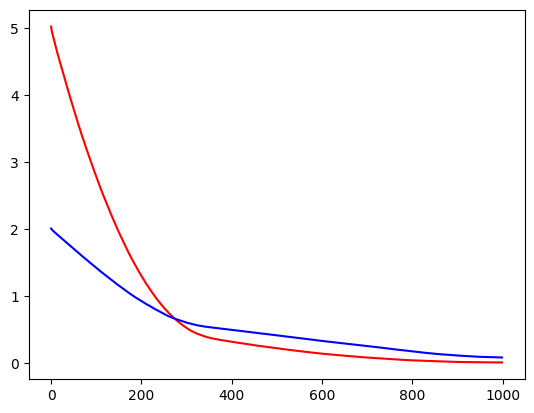

In [51]:
# 6. 학습된 모델 과정 살펴 보기
plt.plot(hist2.history['loss'], c='r')
plt.plot(hist2.history['mae'], c='b')

In [52]:
model2.save('model/after_learning_m2.h5')

In [53]:
# 예측값
y_hat = model2.predict([scaled_data_C])

4/4 [==============================] - 0s 4ms/step


In [54]:
for h, y in zip(y_hat, noised_scaled_data_F):
    print('예측값: {}, 실제값: {}, 오차: {}'.format(h, y, h[0]-y))

예측값: [0.37443092], 실제값: 0.23355100084142544, 오차: 0.14087992381258152
예측값: [0.3912936], 실제값: 0.3754370349737575, 오차: 0.015856550326688035
예측값: [0.40815622], 실제값: 0.3951545693502581, 오차: 0.013001646794303656
예측값: [0.42501888], 실제값: 0.22968783429990616, 오차: 0.1953310424910942
예측값: [0.4418815], 실제값: 0.44063351972417025, 오차: 0.0012479879109463243
예측값: [0.45874417], 실제값: 0.3530527729481503, 오차: 0.10569139533340488
예측값: [0.4756068], 실제값: 0.5706721156648835, 오차: -0.09506531653921213
예측값: [0.49246946], 실제값: 0.46168439837041836, 오차: 0.030785061401691627
예측값: [0.5093321], 실제값: 0.6357730049660235, 오차: -0.12644088454747493
예측값: [0.52619475], 실제값: 0.4361873207113991, 오차: 0.0900074305512657
예측값: [0.5430574], 실제값: 0.4712016133479219, 오차: 0.07185576875885913
예측값: [0.5599201], 실제값: 0.54798083522699, 오차: 0.011939237328551955
예측값: [0.5767827], 실제값: 0.6415948299164539, 오차: -0.06481212651679569
예측값: [0.59364533], 실제값: 0.6105882488627407, 오차: -0.016942914618966243
예측값: [0.61050797], 실제값: 0.44864760562724376,

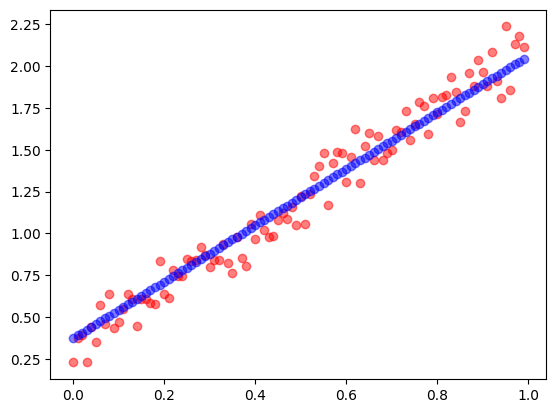

In [55]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F, c='r', alpha=0.5)
plt.scatter(x=scaled_data_C, y=y_hat, c='b', alpha=0.5)
plt.show()